✅ 2D Asset kaydedildi: ../../../assets\47_shm_2d.png


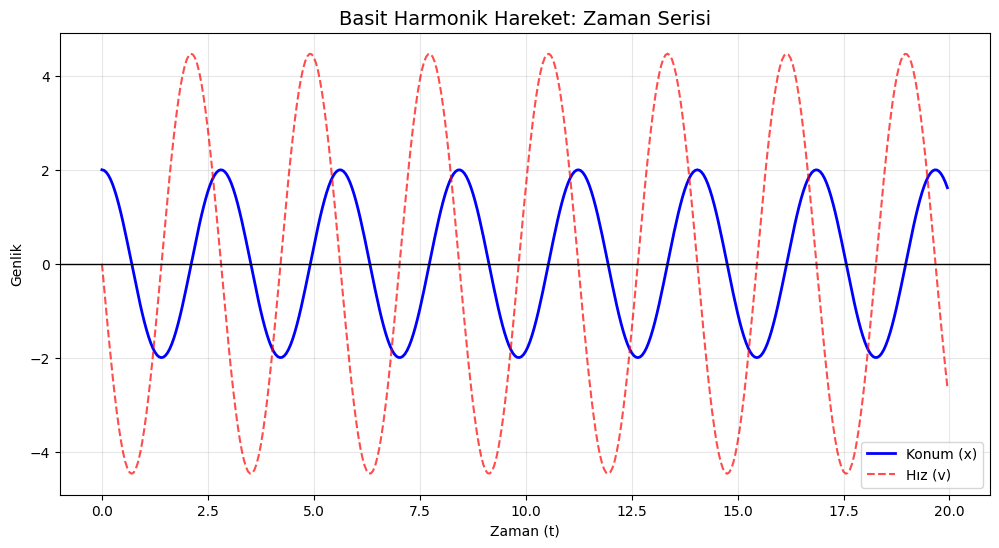

✅ 3D Asset kaydedildi: ../../../assets\47_shm_3d.png


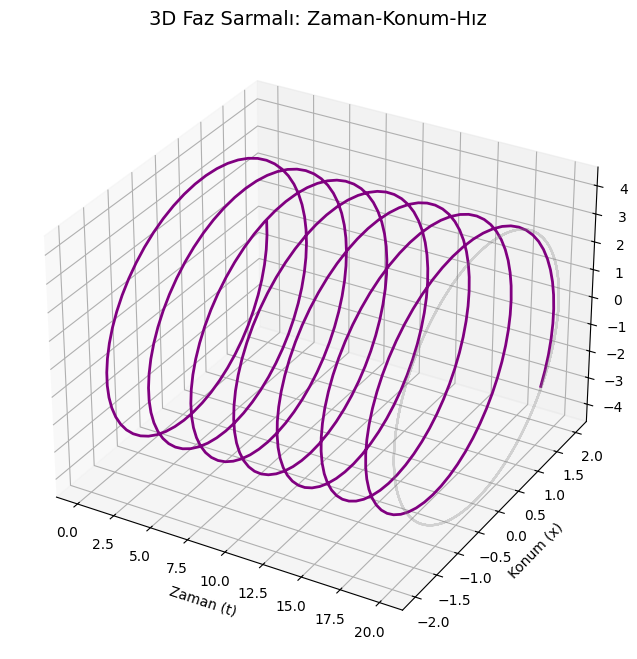

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def run_shm_master():
    # --- 🎯 SENİN YOLUN (FIXED ASSET PATH) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Fiziksel Parametreler
    k = 5.0      # Yay sabiti
    m = 1.0      # Kütle
    omega_sq = k / m
    
    t_end = 20
    dt = 0.05
    t_vals = np.arange(0, t_end, dt)

    # State Vector: [position, velocity]
    # d/dt [x, v] = [v, -omega^2 * x]
    def deriv(state):
        x, v = state
        return np.array([v, -omega_sq * x])

    # 2. RK4 Çözücü
    state = np.array([2.0, 0.0]) # Başlangıç: 2 birim çekilmiş, hız 0
    history = np.zeros((len(t_vals), 2))
    history[0] = state

    for i in range(len(t_vals)-1):
        k1 = deriv(state)
        k2 = deriv(state + dt*k1/2)
        k3 = deriv(state + dt*k2/2)
        k4 = deriv(state + dt*k3)
        state = state + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
        history[i+1] = state

    x_out = history[:, 0]
    v_out = history[:, 1]

    # --- 📸 ASSET 1: 2D POSITION & VELOCITY (47_shm_2d.png) ---
    fig1 = plt.figure(figsize=(12, 6))
    plt.plot(t_vals, x_out, 'b-', lw=2, label='Konum (x)')
    plt.plot(t_vals, v_out, 'r--', lw=1.5, label='Hız (v)', alpha=0.7)
    plt.title("Basit Harmonik Hareket: Zaman Serisi", fontsize=14)
    plt.xlabel("Zaman (t)"); plt.ylabel("Genlik")
    plt.axhline(0, color='black', lw=1)
    plt.legend(); plt.grid(alpha=0.3)
    
    plt.savefig(os.path.join(asset_path, '47_shm_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\47_shm_2d.png")
    plt.show()

    # --- 📸 ASSET 2: 3D PHASE SPIRAL (47_shm_3d.png) ---
    fig2 = plt.figure(figsize=(10, 8))
    ax3d = fig2.add_subplot(111, projection='3d')
    
    ax3d.plot(t_vals, x_out, v_out, color='purple', lw=2)
    ax3d.set_title("3D Faz Sarmalı: Zaman-Konum-Hız", fontsize=14)
    ax3d.set_xlabel('Zaman (t)'); ax3d.set_ylabel('Konum (x)'); ax3d.set_zlabel('Hız (v)')
    
    # Faz diyagramı projeksiyonunu zemine ekle (Enerji korunumu dairesi)
    ax3d.plot(t_vals*0 + t_end, x_out, v_out, color='gray', alpha=0.3, label='Enerji Korunumu (Yörünge)')
    
    plt.savefig(os.path.join(asset_path, '47_shm_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\47_shm_3d.png")
    plt.show()

if __name__ == "__main__":
    run_shm_master()